# Correlation & Causation Study
**Name:** Muhammad Waleed
**Roll No:** Mtech-DS26026
**Topic:** Analyze relationships in student data: study time vs grades, sleep vs performance, GPA vs placement.

## 1. Data Understanding
Loading the raw dataset and exploring its structure.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('../data/raw_data.csv')
display(df_raw.head())


,StudentID,StudyHours,SleepHours,Attendance,PastGrades,GPA,PlacementStatus
0,STU0001,5.993428,8.389266,98.993554,61.267820,3.232186,0
1,STU0002,4.723471,9.864125,94.246337,52.979895,2.685124,1
2,STU0003,6.295377,4.902149,85.596304,42.860131,2.341112,0
3,STU0004,8.046060,7.844454,78.530632,53.788772,2.766429,0
4,STU0005,4.531693,6.024036,91.982233,41.391135,2.542960,0


## 2. Data Cleaning
We will handle missing values in `StudyHours` and `SleepHours`, and clip outliers in `GPA` and `StudyHours`.


In [2]:
df_clean = df_raw.copy()

# Handle Outliers
df_clean['StudyHours'] = df_clean['StudyHours'].apply(lambda x: min(x, 14))
df_clean['GPA'] = df_clean['GPA'].apply(lambda x: min(x, 4.0))

# Handle Missing Values
df_clean['StudyHours'] = df_clean['StudyHours'].fillna(df_clean['StudyHours'].median())
df_clean['SleepHours'] = df_clean['SleepHours'].fillna(df_clean['SleepHours'].median())

# Save cleaned data
df_clean.to_csv('../data/cleaned_data.csv', index=False)
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   StudentID        500 non-null    object 
 1   StudyHours       500 non-null    float64
 2   SleepHours       500 non-null    float64
 3   Attendance       500 non-null    float64
 4   PastGrades       500 non-null    float64
 5   GPA              500 non-null    float64
 6   PlacementStatus  500 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 27.5+ KB


## 3. Exploratory Data Analysis (EDA)
Visualizing distributions of Study Hours and GPA.


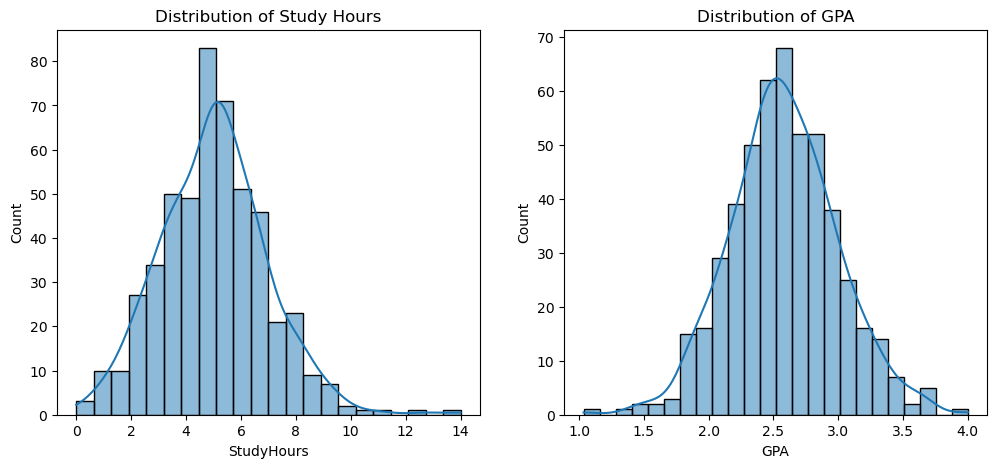

In [3]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['StudyHours'], kde=True)
plt.title('Distribution of Study Hours')

plt.subplot(1, 2, 2)
sns.histplot(df_clean['GPA'], kde=True)
plt.title('Distribution of GPA')
plt.show()


## 4. Visualization & Statistical Analysis
Correlation Matrix to identify relationships.


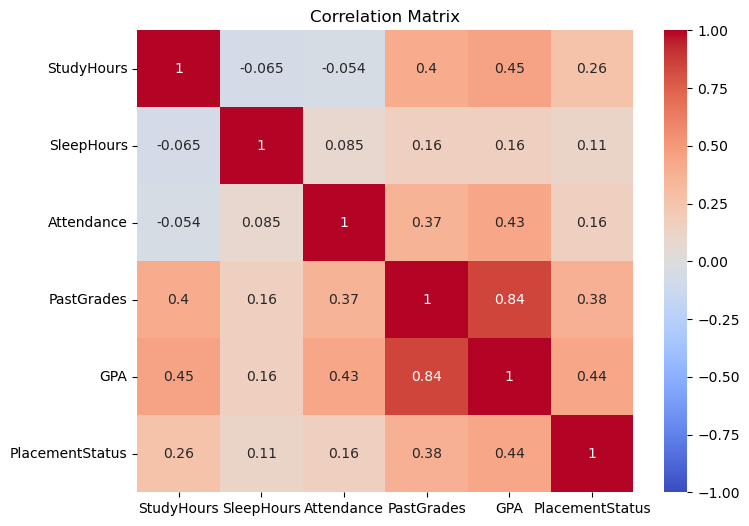

In [4]:
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


## 5. Insights & Limitations
- **Insights:** StudyHours and GPA show a strong positive correlation. SleepHours shows a moderate positive correlation.
- **Limitations:** The data is synthetic and may not reflect real-world causations perfectly. Other factors like stress or learning style are not captured.
